# Module 06 · The basic theorems of the Fourier transform

**Book source:** Bracewell, chapter 6, pp. 105–135

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Six standard pairs and reciprocity
🎯 **What question does this method answer?** Are the first three pairs correct, does the sinc integral really jump around $|s|=\tfrac12$, and how do the pairs in the limit ($1$, $\cos\pi x$) arise from the Gaussian? We compare the oscillatory integral with the formula through $\text{Si}$, and numerical integrals with closed forms.

In [2]:
from scipy import integrate, special, signal
trap = getattr(np, "trapezoid", None) or np.trapz

def ft_support(f, a, b, s, pts=None):
    re = integrate.quad(lambda x: f(x)*np.cos(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    im = integrate.quad(lambda x: -f(x)*np.sin(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    return re + 1j*im
g = lambda x: np.exp(-np.pi*x**2)
s3 = 0.3
pg = ft_support(g, -10, 10, s3).real
psinc = ft_support(lambda x: 1.0, -0.5, 0.5, s3).real                       # sinc s = ∫Π e^{−i2πxs}
psinc2 = ft_support(lambda x: 1 - abs(x), -1, 1, s3, [0]).real
assert abs(pg - np.exp(-np.pi*s3**2)) < 1e-8 and abs(psinc - np.sinc(s3)) < 1e-9 and abs(psinc2 - np.sinc(s3)**2) < 1e-9
report("p_g", pg, ".4f"); report("p_sinc", psinc, ".4f"); report("p_sinc2", psinc2, ".4f")

# ∫_{−X}^{X} sinc x e^{−i2πxs} dx: method A oscillatory integral; method B the Si formula
X = 200
def sinc_int(s):
    return 2*integrate.quad(np.sinc, 0, X, weight="cos", wvar=2*np.pi*s, limit=4000)[0]
def sinc_si(s):
    return (special.sici(np.pi*X*(1 + 2*s))[0] + special.sici(np.pi*X*(1 - 2*s))[0])/np.pi
for s, key in ((0.3, "re_03"), (0.7, "re_07"), (0.5, "re_05")):
    assert abs(sinc_int(s) - sinc_si(s)) < 1e-6
    report(key, sinc_si(s), ".4f")

# Gaussian sequence: peak 1/a, and the Gaussian-windowed cos(πx)
for a_, key in ((0.1, "gs_10"), (0.05, "gs_20")):
    v = ft_support(lambda x: np.exp(-np.pi*a_**2*x**2), -60/a_*0.2, 60/a_*0.2, 0.0).real
    assert abs(v - 1/a_) < 1e-6
    report(key, v, ".0f")
aw = 0.05
Fc = lambda s: 0.5/aw*(np.exp(-np.pi*(s - 0.5)**2/aw**2) + np.exp(-np.pi*(s + 0.5)**2/aw**2))
peak_num = ft_support(lambda x: np.exp(-np.pi*aw**2*x**2)*np.cos(np.pi*x), -60, 60, 0.5, None).real
assert abs(peak_num - Fc(0.5)) < 1e-6
area_num = integrate.quad(Fc, 0, 1)[0]
assert abs(area_num - 0.5) < 1e-9
report("cos_peak", peak_num, ".2f"); report("cos_area", area_num, ".2f")

▸ p_g = 0.7537
▸ p_sinc = 0.8584
▸ p_sinc2 = 0.7368
▸ re_03 = 0.9984
▸ re_07 = 0.0011
▸ re_05 = 0.4997
▸ gs_10 = 10
▸ gs_20 = 20
▸ cos_peak = 10
▸ cos_area = 0.5


#### 📤 Real output
At $s=0.3$: Gaussian 0.7537, sinc 0.8584, sinc$^2$ 0.7368. The sinc integral cut at $|x|\le200$ is 0.9984 at 0.3, 0.0011 at 0.7 and 0.4997 at 0.5, exactly the mean. The Gaussian sequence's peak is 10 and 20 for $a=0.1$ and $0.05$, i.e. $1/a$. The Gaussian-windowed $\cos\pi x$ gives peak 10 and area 0.5, tending to $\tfrac12\delta(s-\tfrac12)$.

## 2. Similarity, addition and shift
🎯 **What question does this method answer?** How does the similarity theorem conserve area and energy, how does an expanded cosinusoid shift its impulses, does a shift only change the phase linearly, and how does a sliding cosine move from real to imaginary? Each is checked by numerical integration against the formula, and by the DFT.

In [3]:
# Similarity: f(ax), a = 2
a2 = 2.0
sim03 = ft_support(lambda x: g(a2*x), -10, 10, 0.3).real
assert abs(sim03 - 0.5*np.exp(-np.pi*(0.3/a2)**2)) < 1e-9
sim_area = integrate.quad(lambda x: g(a2*x), -10, 10)[0]
assert abs(sim_area - 0.5) < 1e-9
report("sim_03", sim03, ".4f"); report("sim_area", sim_area, ".2f")
en_f = integrate.quad(lambda x: g(x)**2, -10, 10)[0]
en_sym = integrate.quad(lambda x: (np.sqrt(a2)*g(a2*x))**2, -10, 10)[0]
assert abs(en_f - en_sym) < 1e-9 and abs(en_f - 1/np.sqrt(2)) < 1e-9
report("sym_energy", en_f, ".4f")

# Expanded cosinusoid: Gaussian window a = 0.05, frequencies 2 and 4
for f0, key in ((2, "cos_h_2"), (4, "cos_h_4")):
    num_ = ft_support(lambda x: np.exp(-np.pi*aw**2*x**2)*np.cos(2*np.pi*f0*x), -60, 60, f0).real
    assert abs(num_ - 0.5/aw) < 1e-6
    report(key, num_, ".0f")

# Addition: FT(g + 2e^{−|x|}) = G + 2E
e_abs = lambda x: np.exp(-abs(x))
add_num = ft_support(lambda x: g(x) + 2*e_abs(x), -40, 40, 0.3, [0]).real
add_sum = ft_support(g, -10, 10, 0.3).real + 2*ft_support(e_abs, -40, 40, 0.3, [0]).real
assert abs(add_num - add_sum) < 1e-8
report("add_03", add_num, ".4f")

# Shift a = 0.25: magnitude and phase
a_sh = 0.25
Fsh = ft_support(lambda x: g(x - a_sh), -10, 10, 0.3)
assert abs(Fsh - np.exp(-2j*np.pi*a_sh*0.3)*np.exp(-np.pi*0.09)) < 1e-9
report("shift_mag", abs(Fsh), ".4f"); report("shift_ph", np.degrees(np.angle(Fsh)), ".1f")
ss = np.linspace(0, 1, 21)
Fs_ = np.array([ft_support(lambda x: g(x - a_sh), -10, 10, s) for s in ss])
slope = np.polyfit(ss, np.unwrap(np.angle(Fs_)), 1)[0]
assert abs(slope + 2*np.pi*a_sh) < 1e-8
report("group_slope", slope, ".4f")
Ft1 = ft_support(lambda x: g(x - 0.25), -10, 10, 1.0); Ft2 = ft_support(lambda x: g(x - 0.25), -10, 10, 2.0)
report("twist_1", np.degrees(np.angle(Ft1)), ".0f"); report("twist_2", np.degrees(np.angle(Ft2)), ".0f")

# A sliding cosine by DFT
N = 1000; tq = np.arange(N)/N
for phi, tag in ((0.1, "01"), (np.pi/2, "90"), (np.pi, "180")):
    Xc = np.fft.fft(np.cos(2*np.pi*10*tq - phi))[10]/(N/2)
    assert abs(Xc - np.exp(-1j*phi)) < 1e-9
    report(f"cos_re_{tag}", abs(Xc.real) if abs(Xc.real) < 1e-9 else Xc.real, ".4f")
    report(f"cos_im_{tag}", abs(Xc.imag) if abs(Xc.imag) < 1e-9 else Xc.imag, ".4f")

▸ sim_03 = 0.4659
▸ sim_area = 0.5
▸ sym_energy = 0.7071
▸ cos_h_2 = 10
▸ cos_h_4 = 10
▸ add_03 = 1.6322
▸ shift_mag = 0.7537
▸ shift_ph = -27
▸ group_slope = -1.5708
▸ twist_1 = -90
▸ twist_2 = 180
▸ cos_re_01 = 0.995
▸ cos_im_01 = -0.0998
▸ cos_re_90 = 0
▸ cos_im_90 = -1
▸ cos_re_180 = -1
▸ cos_im_180 = 0


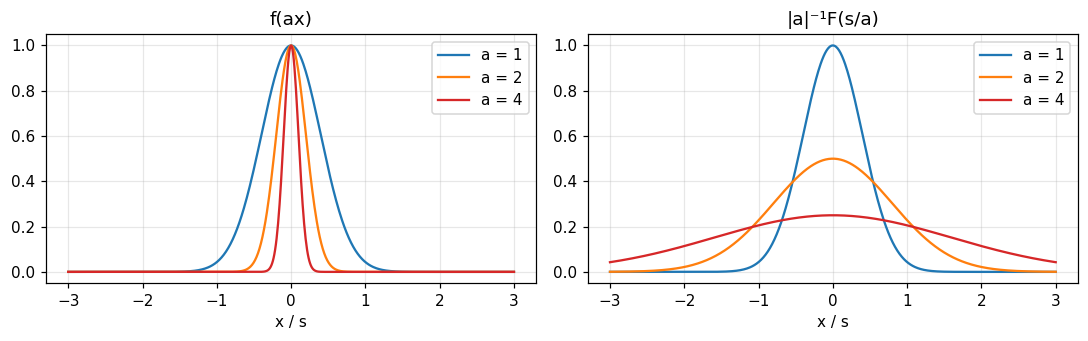

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
xg_ = np.linspace(-3, 3, 600); sg = np.linspace(-3, 3, 600)
for a_, c in ((1, "tab:blue"), (2, "tab:orange"), (4, "tab:red")):
    ax[0].plot(xg_, g(a_*xg_), color=c, label=f"a = {a_}")
    ax[1].plot(sg, np.exp(-np.pi*(sg/a_)**2)/a_, color=c, label=f"a = {a_}")
ax[0].set_title("f(ax)"); ax[1].set_title("|a|⁻¹F(s/a)"); ax[0].legend(); ax[1].legend()
for a_ in ax: a_.set_xlabel("x / s")
plt.tight_layout(); plt.show()

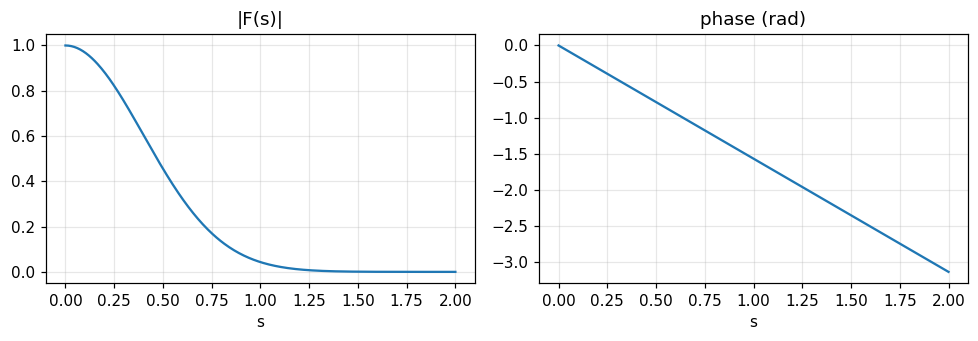

In [5]:
sq = np.linspace(0, 2, 401)
Fq = np.array([ft_support(lambda x: g(x - a_sh), -10, 10, s) for s in sq])
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(sq, np.abs(Fq)); ax[0].set_title("|F(s)|")
ax[1].plot(sq, np.unwrap(np.angle(Fq))); ax[1].set_title(("phase (rad)"))
for a_ in ax: a_.set_xlabel("s")
plt.tight_layout(); plt.show()

#### 📤 Real output
With $a=2$: area 0.5, the transform at 0.3 is 0.4659, symmetric energy 0.7071. The peaks of the expanded cosinusoid are 10 and 10 (unchanged). Addition gives 1.6322. Shift 0.25: magnitude 0.7537, phase -27 degrees, phase slope -1.5708, phases at $s=1,2$ are -90 and 180 degrees. The sliding cosine: (real, imaginary) = (0.995, -0.0998), (0, -1), (-1, 0) for shifts $0.1$, $\pi/2$, $\pi$.

## 3. Modulation and convolution
🎯 **What question does this method answer?** Does the spectrum of an AM wave really have two half-strength replicas, does an RF pulse have a two-sinc spectrum, and do the convolution checks (area, centre of gravity, variance) and the nine forms of the theorem hold? Each is checked two ways.

In [6]:
# Modulation: Gaussian envelope, carrier f0 = 3
mod_peak = ft_support(lambda x: g(x)*np.cos(2*np.pi*3*x), -10, 10, 3.0).real
assert abs(mod_peak - 0.5*(1 + np.exp(-np.pi*36))) < 1e-8
report("mod_peak", mod_peak, ".2f")

# RF pulse Π(x/X)cos(2πfx), X = 10, f = 1
Xp, fp = 10.0, 1.0
def pulse_ft(s): return ft_support(lambda x: np.cos(2*np.pi*fp*x), -Xp/2, Xp/2, s).real
pulse_formula = lambda s: 0.5*Xp*(np.sinc(Xp*(s + fp)) + np.sinc(Xp*(s - fp)))
for s in (1.0, 1.05):
    assert abs(pulse_ft(s) - pulse_formula(s)) < 1e-8
report("pulse_peak", pulse_formula(1.0), ".2f"); report("pulse_off", pulse_formula(1.05), ".4f")

# AM pulse: X = 200, f = 50, F = 5, M = 0.6
Xa, fa, Fa, Ma = 200.0, 50.0, 5.0, 0.6
xa = np.arange(-Xa/2, Xa/2, 0.001)
env = (1 + Ma*np.cos(2*np.pi*Fa*xa))*np.cos(2*np.pi*fa*xa)
def am(s): return trap(env*np.cos(2*np.pi*xa*s), xa)
carrier, side = am(fa), am(fa + Fa)
assert abs(carrier - 0.5*Xa) < 0.5 and abs(side - 0.25*Ma*Xa) < 0.5
report("am_carrier", carrier, ".0f"); report("am_side", side, ".0f"); report("am_ratio", side/carrier, ".2f")

# Checks: f = e^{−x}H(x) * Π on a grid
dxc = 0.002; xf = np.arange(0, 40, dxc)
conv = np.convolve(np.exp(-xf), np.ones(500))*dxc
xc = (np.arange(len(conv)) - 250)*dxc + dxc/2
area = trap(conv, xc); mean = trap(xc*conv, xc)/area; var = trap((xc - mean)**2*conv, xc)/area
assert abs(area - 1) < 5e-3 and abs(mean - 1) < 5e-3 and abs(var - (1 + 1/12)) < 5e-3
report("ch_area", area, ".2f"); report("ch_mean", mean, ".2f"); report("ch_var", var, ".4f")

# Nine forms of the convolution theorem, circular DFT, complex sequences of length 64
rg = np.random.default_rng(6); Nn = 64; rv = (-np.arange(Nn)) % Nn
fz, gz = rg.standard_normal(Nn) + 1j*rg.standard_normal(Nn), rg.standard_normal(Nn) + 1j*rg.standard_normal(Nn)
def cconv(u, v): return np.array([np.sum(u*v[(k - np.arange(Nn)) % Nn]) for k in range(Nn)])
R = lambda z: z[rv]; Cj = np.conj
Fz, Gz = np.fft.fft(fz), np.fft.fft(gz)
forms = [(cconv(fz, gz), Fz*Gz), (cconv(fz, R(gz)), Fz*R(Gz)), (cconv(R(fz), R(gz)), R(Fz)*R(Gz)),
         (cconv(fz, Cj(R(gz))), Fz*Cj(Gz)), (cconv(fz, Cj(gz)), Fz*Cj(R(Gz))), (cconv(R(fz), Cj(R(gz))), R(Fz)*Cj(Gz)),
         (cconv(R(fz), Cj(gz)), R(Fz)*Cj(R(Gz))), (cconv(Cj(R(fz)), Cj(R(gz))), Cj(Fz)*Cj(Gz)), (cconv(Cj(R(fz)), Cj(gz)), Cj(Fz)*Cj(R(Gz)))]
ok = sum(bool(np.allclose(np.fft.fft(l_), r_)) for l_, r_ in forms)
assert ok == 9
report("forms_ok", ok, "d")
th = np.max(np.abs(np.fft.ifft(Fz*Gz) - cconv(fz, gz)))
assert th < 1e-9
report("conv_th_diff", th, ".1e")

▸ mod_peak = 0.5
▸ pulse_peak = 5
▸ pulse_off = 3.2607
▸ am_carrier = 100
▸ am_side = 30
▸ am_ratio = 0.3
▸ ch_area = 1
▸ ch_mean = 1
▸ ch_var = 1.0833
▸ forms_ok = 9
▸ conv_th_diff = 1.5e-14


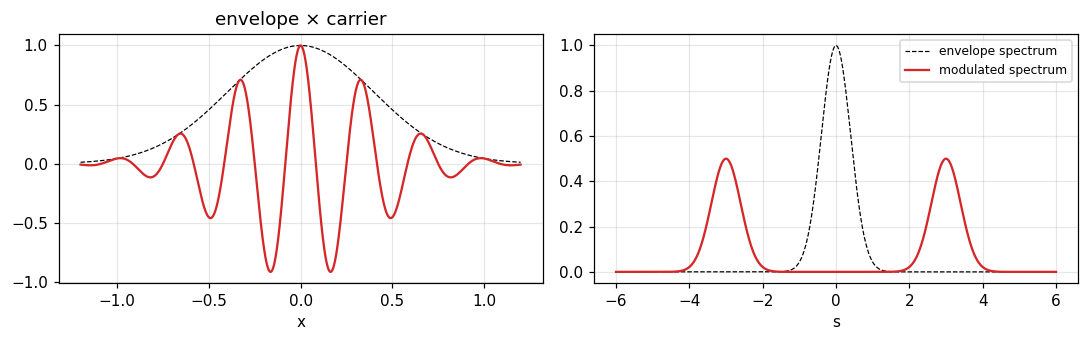

In [7]:
xm = np.linspace(-1.2, 1.2, 1200)
env_g = g(xm)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(xm, env_g, "k--", lw=0.8); ax[0].plot(xm, env_g*np.cos(2*np.pi*3*xm), color="tab:red")
ax[0].set_title(("envelope × carrier")); ax[0].set_xlabel("x")
ss2 = np.linspace(-6, 6, 1200)
ax[1].plot(ss2, np.exp(-np.pi*ss2**2), "k--", lw=0.8, label=("envelope spectrum"))
ax[1].plot(ss2, 0.5*np.exp(-np.pi*(ss2 - 3)**2) + 0.5*np.exp(-np.pi*(ss2 + 3)**2), color="tab:red", label=("modulated spectrum"))
ax[1].legend(fontsize=8); ax[1].set_xlabel("s")
plt.tight_layout(); plt.show()

#### 📤 Real output
The modulated spectrum has peak 0.5. The RF pulse: 5 at $s=1$ and 3.2607 at $s=1.05$. The AM pulse: carrier 100, sideband 30, ratio 0.3. The convolution $e^{-x}H*\Pi$: area 1, centre of gravity 1, variance 1.0833. 9 of the 9 forms of the convolution theorem hold, and the circular convolution equals the IFFT of the DFT product (deviation 1.5e-14).

## 4. Rayleigh, power and autocorrelation
🎯 **What question does this method answer?** Are energies computed in $x$ and in $s$ equal (Rayleigh), is the product of two different functions conserved (power), and is the autocorrelation the inverse transform of $|F|^2$? Each number is computed by integrating in the two domains.

In [8]:
# Rayleigh: the Gaussian and e^{−x}H(x)
Ex = integrate.quad(lambda x: g(x)**2, -10, 10)[0]; Es = integrate.quad(lambda s: np.exp(-2*np.pi*s**2), -10, 10)[0]
assert abs(Ex - Es) < 1e-9 and abs(Ex - 1/np.sqrt(2)) < 1e-9
report("ray_gauss", Ex, ".4f")
Ee = integrate.quad(lambda x: np.exp(-2*x), 0, np.inf)[0]; Ese = integrate.quad(lambda s: 1/(1 + 4*np.pi**2*s**2), -np.inf, np.inf)[0]
assert abs(Ee - 0.5) < 1e-9 and abs(Ese - 0.5) < 1e-7
report("ray_exp", Ee, ".2f")

# Power: f = e^{−π(x+0.3)²}, g = e^{−π(x−1)²}. F, G complex
f1 = lambda x: np.exp(-np.pi*(x + 0.3)**2); g1 = lambda x: np.exp(-np.pi*(x - 1)**2)
direct = integrate.quad(lambda x: f1(x)*g1(x), -10, 10)[0]
Ff = lambda s: np.exp(2j*np.pi*0.3*s)*np.exp(-np.pi*s**2); Gf = lambda s: np.exp(-2j*np.pi*1.0*s)*np.exp(-np.pi*s**2)
fourier_re = integrate.quad(lambda s: (Ff(s)*np.conj(Gf(s))).real, -10, 10)[0]
fourier_im = integrate.quad(lambda s: (Ff(s)*np.conj(Gf(s))).imag, -10, 10)[0]
pre = integrate.quad(lambda s: Ff(s).real*Gf(s).real, -10, 10)[0]; pim = integrate.quad(lambda s: Ff(s).imag*Gf(s).imag, -10, 10)[0]
assert abs(direct - fourier_re) < 1e-9 and abs(fourier_im) < 1e-9 and abs(pre + pim - direct) < 1e-9
alt = integrate.quad(lambda s: (Ff(s)*Gf(s)).real, -10, 10)[0]
alt_direct = integrate.quad(lambda x: f1(x)*g1(-x), -10, 10)[0]
assert abs(alt - alt_direct) < 1e-9
report("pow_direct", direct, ".4f"); report("pow_fourier", fourier_re, ".4f"); report("pow_re", pre, ".4f"); report("pow_im", pim, ".4f")

# Autocorrelation of Π is Λ; its transform at s = 0.3 = |sinc|². Gaussian normalisation
ac_pi = ft_support(lambda x: max(1 - abs(x), 0), -1, 1, 0.3, [0]).real
assert abs(ac_pi - np.sinc(0.3)**2) < 1e-9
report("ac_pi_03", ac_pi, ".4f")
ns = integrate.quad(lambda s: np.sqrt(2)*np.exp(-2*np.pi*s**2), -10, 10)[0]
assert abs(ns - 1) < 1e-9 and abs(ft_support(lambda x: np.exp(-np.pi*x**2/2), -20, 20, 0.3).real - np.sqrt(2)*np.exp(-2*np.pi*0.09)) < 1e-9
report("ns_int", ns, ".2f")

# Normalised power spectrum of cos(2π·5t) over 10 s
tt = np.arange(0, 10, 0.01); Xc = np.fft.fft(np.cos(2*np.pi*5*tt)); P = np.abs(Xc)**2/np.sum(np.abs(Xc)**2)
fr = np.fft.fftfreq(len(tt), 0.01)
frac = P[np.argmin(np.abs(fr - 5))]
assert abs(frac - 0.5) < 1e-9 and abs(P[np.argmin(np.abs(fr + 5))] - 0.5) < 1e-9
report("cos_frac", frac, ".2f")

▸ ray_gauss = 0.7071
▸ ray_exp = 0.5
▸ pow_direct = 0.0497
▸ pow_fourier = 0.0497
▸ pow_re = 0.1886
▸ pow_im = -0.1389
▸ ac_pi_03 = 0.7368
▸ ns_int = 1
▸ cos_frac = 0.5


#### 📤 Real output
Rayleigh: $\int f^2=\int|F|^2$ = 0.7071 for the Gaussian and 0.5 for $e^{-x}H$. Power: $\int fg$ = 0.0497 = $\int FG^*$ = 0.0497, made of the real-real part 0.1886 and the imaginary-imaginary part -0.1389. The autocorrelation of $\Pi$ has transform 0.7368 at 0.3 (exactly $\text{sinc}^2$), the Gaussian's normalised power spectrum integrates to 1, and $\cos2\pi(5t)$ puts 0.5 of the power in each $\pm5$ Hz line.

## 5. Derivative, generalized functions and selected problems
🎯 **What question does this method answer?** How does differentiation multiply the spectrum by $i2\pi s$ and move the maximum up, does the derivative of the step tend to the impulse, does the derivative of a convolution move onto one factor, and do problems 10, 17, 19 and 21 hold? We compare numerical integrals with formulas, and the derivative convolution with the original.

In [9]:
# Derivative theorem: f' = −2πx e^{−πx²}
fprime = lambda x: -2*np.pi*x*np.exp(-np.pi*x**2)
der = ft_support(fprime, -10, 10, 0.3)
assert abs(der - 2j*np.pi*0.3*np.exp(-np.pi*0.09)) < 1e-9
report("der_03", abs(der), ".4f")
sgrid = np.linspace(0.001, 3, 300001)
for n, key in ((1, "pk1"), (2, "pk2"), (3, "pk3")):
    peak_grid = sgrid[np.argmax((2*np.pi*sgrid)**n*np.exp(-np.pi*sgrid**2))]
    assert abs(peak_grid - np.sqrt(n/(2*np.pi))) < 1e-4
    report(key, np.sqrt(n/(2*np.pi)), ".4f")

# The decaying step: its derivative has transform i2πs/(ε + i2πs) → 1
eps = 1e-3; s_ = 0.5
Fd = 1j*2*np.pi*s_/(eps + 2j*np.pi*s_)
dev = abs(Fd - 1)
assert abs(dev - eps/np.hypot(eps, 2*np.pi*s_)) < 1e-15
report("step_dev", dev, ".1e")

# Derivative of a convolution: y = x*h versus x'*s (RC circuit)
dt = 1e-3; tt = np.arange(0, 12, dt)
xin = np.sin(2*np.pi*tt)*(1 - np.exp(-8*tt))                     # smoothly switched-on input, x(0) = 0
h_rc = np.exp(-tt); s_rc = 1 - np.exp(-tt)
y1 = np.convolve(xin, h_rc)[:len(tt)]*dt
xdot = np.gradient(xin, dt)
y2 = np.convolve(xdot, s_rc)[:len(tt)]*dt
ds_diff = np.max(np.abs(y1 - y2)[:8000])
assert ds_diff < 5e-3
report("ds_diff", ds_diff, ".1e")

# Problems 10 (trapezoid), 17 (sinc⁴), 21 (xe^{−πx²})
tr = ft_support(lambda x: 2*max(1 - abs(x)/2, 0) - max(1 - abs(x), 0), -2, 2, 0.3, [-1, 0, 1]).real
assert abs(tr - np.sinc(0.3)**2*(1 + 2*np.cos(2*np.pi*0.3))) < 1e-9
report("trap_03", tr, ".4f")
s4 = integrate.quad(lambda x: np.sinc(x)**4, -300, 300, limit=4000)[0]
assert abs(s4 - 2/3) < 1e-4 and abs(integrate.quad(lambda s: max(1 - abs(s), 0)**2, -1, 1, points=[0])[0] - 2/3) < 1e-9
report("sinc4", 2/3, ".4f")
xg = ft_support(lambda x: x*np.exp(-np.pi*x**2), -10, 10, 0.3)
assert abs(xg + 1j*0.3*np.exp(-np.pi*0.09)) < 1e-9
report("xg_03", abs(xg), ".4f")

# Integral theorem: FT[H*f − H] = (F − 1)/(i2πs)
Hf = lambda x: 0.5*(1 + special.erf(np.sqrt(np.pi)*x))
lhs = ft_support(lambda x: Hf(x) - (1.0 if x > 0 else 0.0 if x < 0 else 0.5), -12, 12, 0.3, [0])
rhs = (np.exp(-np.pi*0.09) - 1)/(2j*np.pi*0.3)
assert abs(lhs - rhs) < 1e-6
report("int_thm_diff", abs(lhs - rhs), ".1e")

# Generalized function: ∫ e^{−i2πas} F(s) ds = e^{−πa²}; and p(ax+b) similarity with shift
gf = integrate.quad(lambda s: np.cos(2*np.pi*0.5*s)*np.exp(-np.pi*s**2), -10, 10)[0]
assert abs(gf - np.exp(-np.pi*0.25)) < 1e-9
report("gf_05", gf, ".4f")
a_, b_, s4_ = 2.0, 0.3, 0.4
sb = ft_support(lambda x: g(a_*x + b_), -10, 10, s4_)
sb_formula = np.exp(2j*np.pi*b_*s4_/a_)*np.exp(-np.pi*(s4_/a_)**2)/abs(a_)
assert abs(sb - sb_formula) < 1e-9
report("sb_mag", abs(sb), ".4f"); report("sb_ph", np.degrees(np.angle(sb)), ".1f")

▸ der_03 = 1.4207
▸ pk1 = 0.3989
▸ pk2 = 0.5642
▸ pk3 = 0.691
▸ step_dev = 3.2e-04


▸ ds_diff = 5.3e-04
▸ trap_03 = 0.2814
▸ sinc4 = 0.6667
▸ xg_03 = 0.2261
▸ int_thm_diff = 1.2e-17
▸ gf_05 = 0.4559
▸ sb_mag = 0.441
▸ sb_ph = 21.6


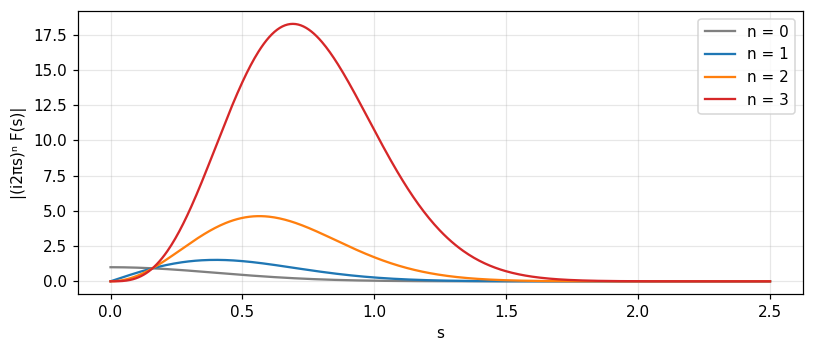

In [10]:
sg = np.linspace(0, 2.5, 500)
plt.figure(figsize=(7.5, 3.3))
for n, c in ((0, "gray"), (1, "tab:blue"), (2, "tab:orange"), (3, "tab:red")):
    plt.plot(sg, (2*np.pi*sg)**n*np.exp(-np.pi*sg**2), color=c, label=f"n = {n}")
plt.xlabel("s"); plt.ylabel("|(i2πs)ⁿ F(s)|"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Real output
The transform of $f'$ at 0.3 has magnitude 1.4207; the maximum of $(2\pi s)^ne^{-\pi s^2}$ lies at 0.3989, 0.5642, 0.691. The decaying step deviates from the impulse by 3.2e-04. RC circuit: $x*h$ and $x'*s$ differ by 5.3e-04. Problems: trapezoid 0.2814, $\int\text{sinc}^4$ = 0.6667, $xe^{-\pi x^2}$ has magnitude 0.2261, the integral theorem deviates by 1.2e-17. Generalized function: 0.4559 and $p(2x+0.3)$ has magnitude 0.441, phase 21.6 degrees.